# Anomaly Detection for Greenhouse Digital Twin

## IJC308 Data Science Portfolio - Component 3

**Date:** 19 January 2026




The objective of this software component is to extend the greenhouse Digital Twin with a data-driven anomaly detection capability to detect unusual patterns in greenhouse sensor data. The notebook implements a comprehensive anomaly detection pipeline for greenhouse sensor data, featuring three different anomaly detection algorithms spanning classification (**One-Class SVM**), clustering (**Local Outlier Factor**)and statistical modelling (**Isolation Forest**). The implementation includes a consensus voting mechanism to merge the predictions of the chosen detectors, visualisation tools including PCA projections and time-series anomaly highlighting, and comparative analysis of algorithm performance.


---

## 1. Setup

In [1]:
# Importing libraries

#requests: to get data from the internet(API)
import requests
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#sklearn: machine learning library
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries successfully imported")

Libraries successfully imported


---

## 2. Getting Data from API

In [2]:
# Fetching data from Greenhouse API

# API URL of the greenhouse data
# We use /data with start and end parameters to fetch a specific date range
API_URL = "http://greenhouse.shef.ac.uk:7070/data"

def fetch_greenhouse_dataAPI(start, end):
    """
    Fetch data from Sheffield greenhouse API.
    Parameters: start : string
        the start date in format 'YYYY-MM-DD'
    end : string
        the end date in format 'YYYY-MM-DD'

    Returns: pd.DataFrame : Greenhouse sensor data
    """
    url = f"{API_URL}?start={start}&end={end}"

    try:
        response = requests.get(url, timeout=60) # the API request
        response.raise_for_status()
        data = response.json()

        # Parse the data
        if 'data' in data:
            df = pd.DataFrame(data['data'])
        else:
            df = pd.DataFrame(data)

        print(f" Successfully fetched {len(df)} records")
        return df

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
        return None

# Fetching data from API with fixed date range
fetched_data= fetch_greenhouse_dataAPI("2025-12-14", "2026-01-18")

 Successfully fetched 10081 records


In [3]:
#For SOURCE DATA
#Saves fetched data to CSV
if fetched_data is not None:
    fetched_data.to_csv('fetched_data.csv', index=False)
    print(f" Data saved to 'fetched_data.csv'")

 Data saved to 'fetched_data.csv'


In [4]:
#Showing first 5 rows
print("First 5 rows of data:")
print("="*50)
fetched_data.head()

First 5 rows of data:


,timestamp,outdoor_global_radiation,outdoor_air_temp,outdoor_rh,outdoor_wind_speed,indoor_temperature,indoor_vpd,energy_screen_closure,blackout_screen_closure,lee_vent_aperture,...,14,15,16,17,18,19,20,21,co2_injection_status,indoor_co2
0,2025-12-14T00:00:00,0.0,-0.5,91.5,0.0,16.9,2.276594,94.0,100.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,754.0
1,2025-12-14T00:05:02.399999,0.0,-0.5,91.7,0.0,17.8,2.809749,91.0,100.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,761.0
2,2025-12-14T00:09:56.160003,0.0,-0.5,92.0,0.0,18.4,3.224325,81.0,99.5,5.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,711.0
3,2025-12-14T00:14:58.560002,0.0,-0.5,92.4,0.0,18.8,3.525584,31.0,97.5,5.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,747.0
4,2025-12-14T00:20:00.960002,0.0,-0.6,92.3,0.0,18.9,3.514139,0.0,97.5,5.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,707.0


In [5]:
print(f"Data shape: {fetched_data.shape[0]} rows x {fetched_data.shape[1]} columns")

# the columns we have
print(f"\nColumns: {list(fetched_data.columns)}")

Data shape: 10081 rows x 24 columns

Columns: ['timestamp', 'outdoor_global_radiation', 'outdoor_air_temp', 'outdoor_rh', 'outdoor_wind_speed', 'indoor_temperature', 'indoor_vpd', 'energy_screen_closure', 'blackout_screen_closure', 'lee_vent_aperture', 'wind_vent_aperture', 'pipe_rail_inlet_temp', 'grow_pipes_inlet_temp', 'lights_on', '14', '15', '16', '17', '18', '19', '20', '21', 'co2_injection_status', 'indoor_co2']


---

## 3. Data Exploration

Before building the anomaly detection model, this section explores the data to understand its structure, distributions, and any obvious patterns

In [6]:
#Converts timestamp from text to a proper datetime format
fetched_data['timestamp'] = pd.to_datetime(fetched_data['timestamp'], format='ISO8601')

#shows the time range of the data
print(f"Data time range:")
print(f"  Start: {fetched_data['timestamp'].min()}")    # First reading
print(f"  End:   {fetched_data['timestamp'].max()}")    # Last reading
print(f"  Duration: {fetched_data['timestamp'].max() - fetched_data['timestamp'].min()}")  # How long



Data time range:
  Start: 2025-12-14 00:00:00
  End:   2026-01-18 00:00:00
  Duration: 35 days 00:00:00


In [7]:
# Data types and info
print("\n Data Types:")
print(fetched_data.dtypes)



 Data Types:
timestamp                   datetime64[ns]
outdoor_global_radiation           float64
outdoor_air_temp                   float64
outdoor_rh                         float64
outdoor_wind_speed                 float64
indoor_temperature                 float64
indoor_vpd                         float64
energy_screen_closure              float64
blackout_screen_closure            float64
lee_vent_aperture                  float64
wind_vent_aperture                 float64
pipe_rail_inlet_temp               float64
grow_pipes_inlet_temp              float64
lights_on                          float64
14                                 float64
15                                 float64
16                                 float64
17                                 float64
18                                 float64
19                                 float64
20                                 float64
21                                 float64
co2_injection_status               float

In [8]:
print("Summary statistics of sensor readings:")
numeric_cols = fetched_data.select_dtypes(include=[np.number]).columns.tolist()
fetched_data[numeric_cols].describe().round(2)

Summary statistics of sensor readings:


,outdoor_global_radiation,outdoor_air_temp,outdoor_rh,outdoor_wind_speed,indoor_temperature,indoor_vpd,energy_screen_closure,blackout_screen_closure,lee_vent_aperture,wind_vent_aperture,...,14,15,16,17,18,19,20,21,co2_injection_status,indoor_co2
count,10081.00,10081.00,10081.00,10081.00,10081.00,10081.00,10081.00,10081.00,10081.00,10081.0,...,10081.0,10081.0,10081.0,10081.0,10081.0,10081.0,10081.0,10081.0,10081.00,10081.00
mean,29.40,-0.36,89.14,2.57,20.19,3.23,42.69,41.30,1.64,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11,1073.00
std,61.05,2.74,7.32,2.48,3.19,1.11,48.31,48.11,3.21,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.31,158.59
min,0.00,-8.20,60.50,0.00,14.00,0.98,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,503.00
25%,0.00,-2.10,85.00,0.00,18.30,2.46,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1079.00
50%,0.00,-0.30,90.20,2.40,20.30,3.19,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1120.00
75%,25.00,1.00,95.20,4.20,22.10,3.78,98.80,99.00,2.20,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1159.00
max,354.00,7.30,98.20,13.30,27.90,7.31,100.00,100.00,23.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,1707.00


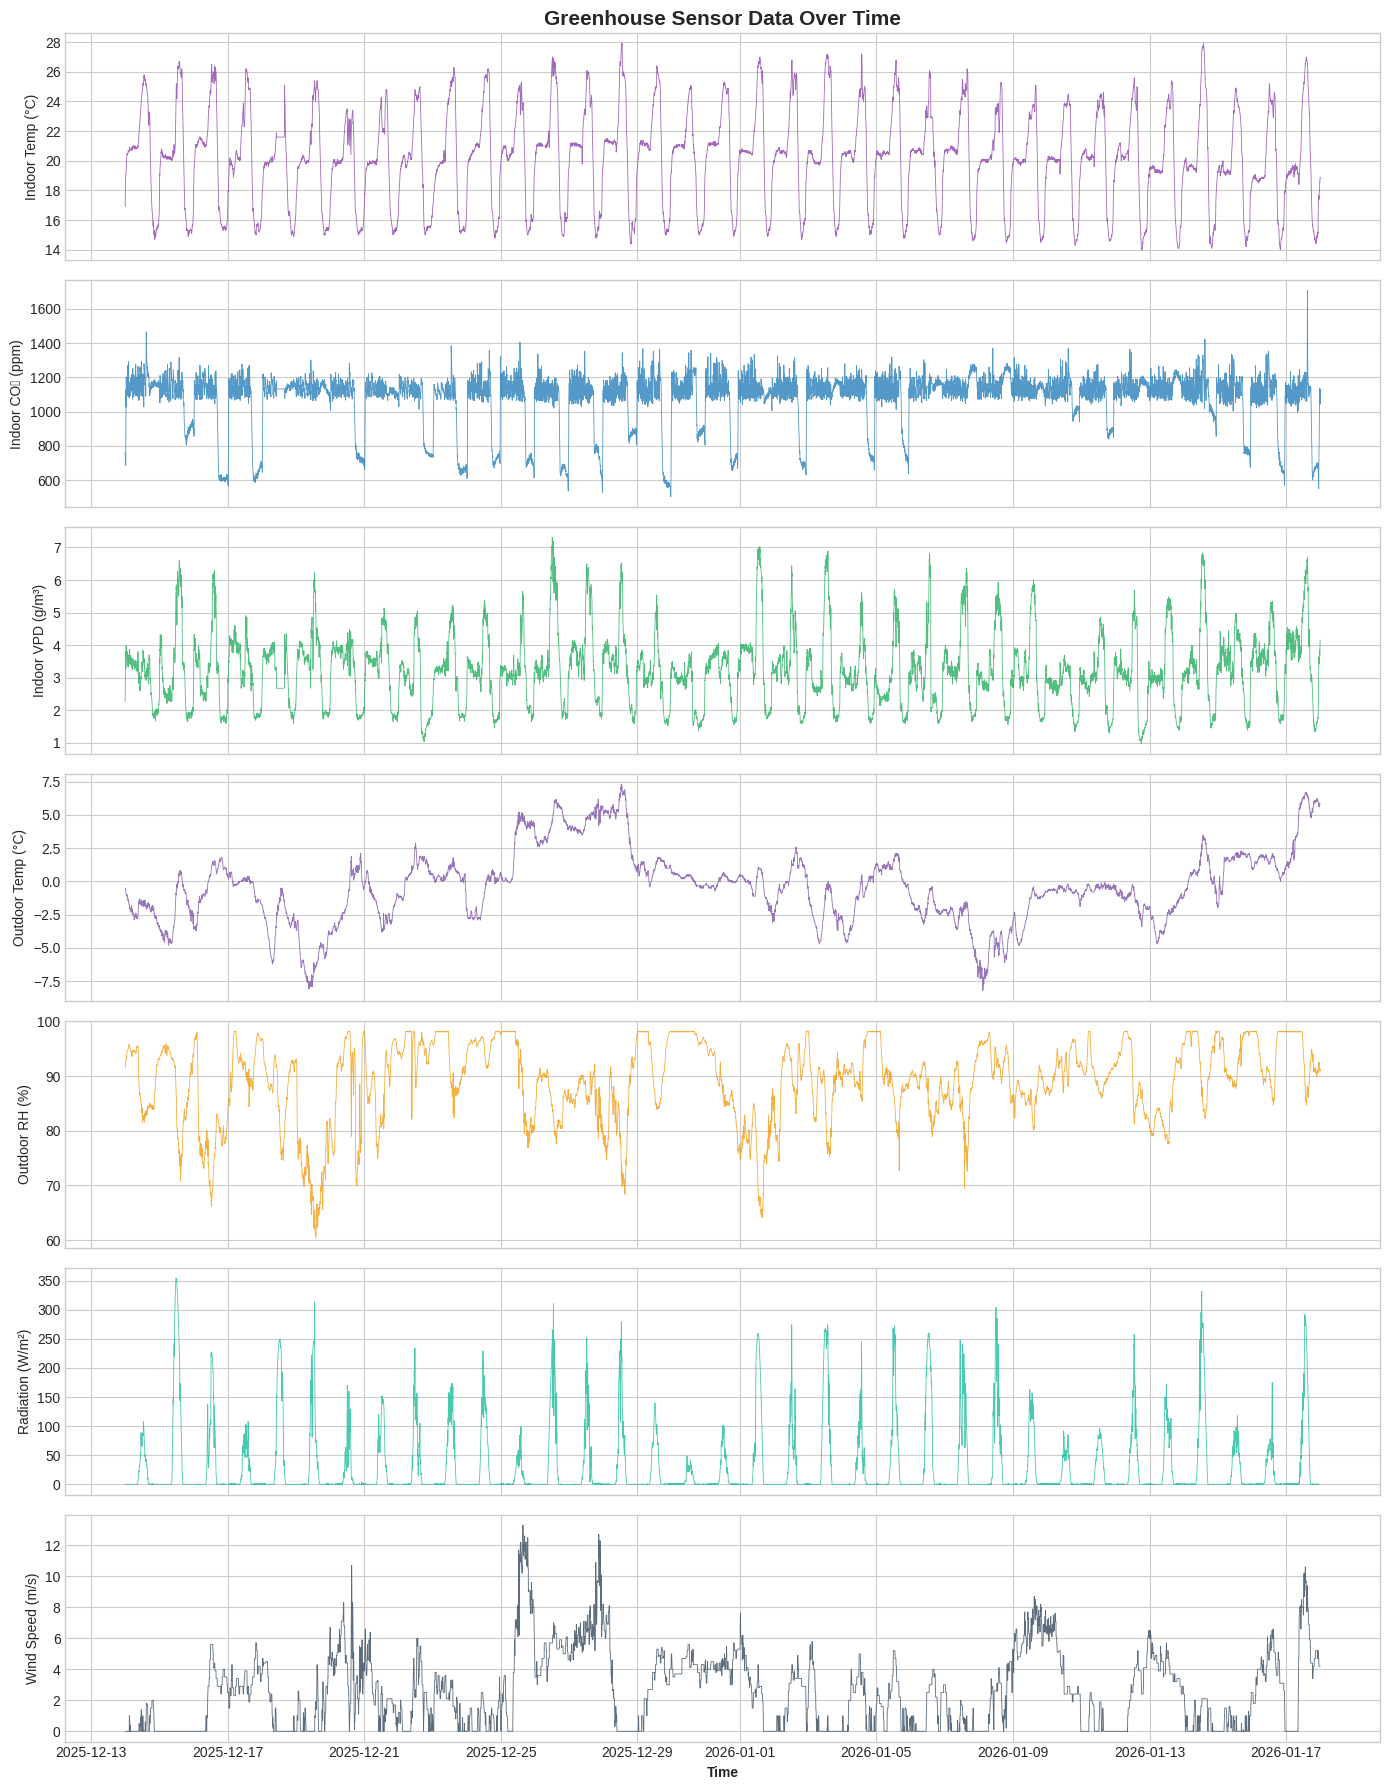

In [9]:
#Visualising all 7 important sensor features over time

fig, axes = plt.subplots(7, 1, figsize=(14, 18), sharex=True)

axes[0].set_title('Greenhouse Sensor Data Over Time', fontsize=15, fontweight='bold')

# Plot 1: Indoor Temperature
axes[0].plot(fetched_data['timestamp'], fetched_data['indoor_temperature'],
             color='#8E44AD', linewidth=0.6, alpha=0.8)
axes[0].set_ylabel('Indoor Temp (°C)', fontsize=10)

# Plot 2: Indoor CO2
axes[1].plot(fetched_data['timestamp'], fetched_data['indoor_co2'],
             color='#2980B9', linewidth=0.6, alpha=0.8)
axes[1].set_ylabel('Indoor CO₂ (ppm)', fontsize=10)

# Plot 3: Indoor VPD
axes[2].plot(fetched_data['timestamp'], fetched_data['indoor_vpd'],
             color='#27AE60', linewidth=0.6, alpha=0.8)
axes[2].set_ylabel('Indoor VPD (g/m³)', fontsize=10)

# Plot 4: Outdoor Temperature
axes[3].plot(fetched_data['timestamp'], fetched_data['outdoor_air_temp'],
             color='#7E55AB', linewidth=0.6, alpha=0.8)
axes[3].set_ylabel('Outdoor Temp (°C)', fontsize=10)

# Plot 5: Outdoor Humidity
axes[4].plot(fetched_data['timestamp'], fetched_data['outdoor_rh'],
             color='#F39C12', linewidth=0.6, alpha=0.8)
axes[4].set_ylabel('Outdoor RH (%)', fontsize=10)

# Plot 6: Outdoor Radiation
axes[5].plot(fetched_data['timestamp'], fetched_data['outdoor_global_radiation'],
             color='#1ABC9C', linewidth=0.6, alpha=0.8)
axes[5].set_ylabel('Radiation (W/m²)', fontsize=10)

# Plot 7: Outdoor Wind Speed
axes[6].plot(fetched_data['timestamp'], fetched_data['outdoor_wind_speed'],
             color='#34495E', linewidth=0.6, alpha=0.8)
axes[6].set_ylabel('Wind Speed (m/s)', fontsize=10)

axes[6].set_xlabel('Time', fontsize=10, fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

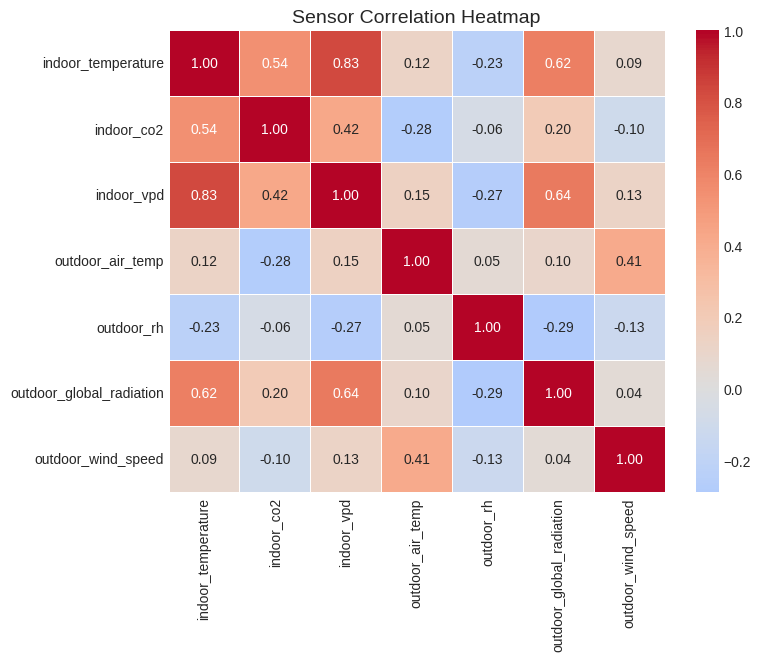

   High positive correlation indicates sensors increase together.
   High negative correlation indicates one increases as other decreases.


In [10]:
#Correlation heatmap
sensor_columns = ['indoor_temperature', 'indoor_co2', 'indoor_vpd',
               'outdoor_air_temp', 'outdoor_rh', 'outdoor_global_radiation', 'outdoor_wind_speed']

corr_matrix = fetched_data[sensor_columns].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0, linewidths=0.4)
plt.title('Sensor Correlation Heatmap', fontsize=14)
plt.show()

print("   High positive correlation indicates sensors increase together.")
print("   High negative correlation indicates one increases as other decreases.")

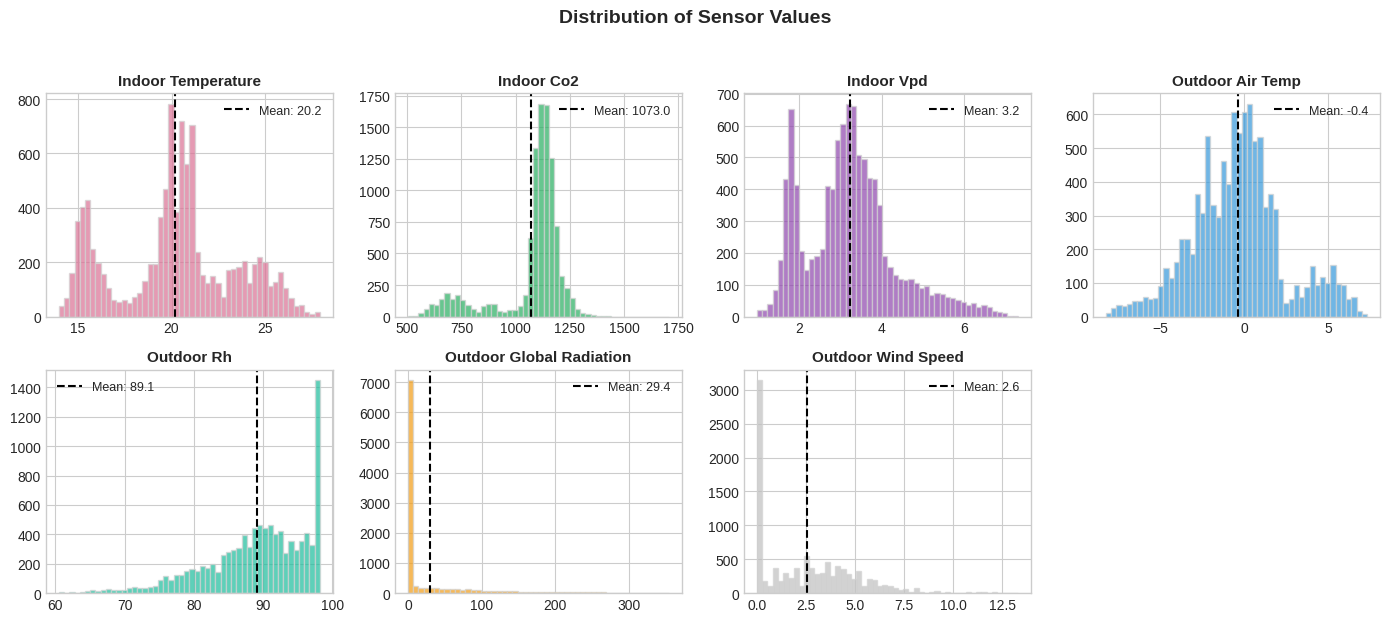

In [11]:
# Distribution of key sensors
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

colors = ['#DB7093', '#27ae60', '#8E44AD', '#3498db', '#1abc9c', '#f39c12', 'silver']

for ax, sensor, color in zip(axes.flatten(), sensor_columns, colors):
    ax.hist(fetched_data[sensor], bins=50, color=color, alpha=0.7, edgecolor='lightgrey')
    ax.axvline(fetched_data[sensor].mean(), color='black', linestyle='--', label=f'Mean: {fetched_data[sensor].mean():.1f}')
    ax.set_title(sensor.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
axes[1, 3].axis('off') #hiding the last non-existing plot

plt.suptitle('Distribution of Sensor Values', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

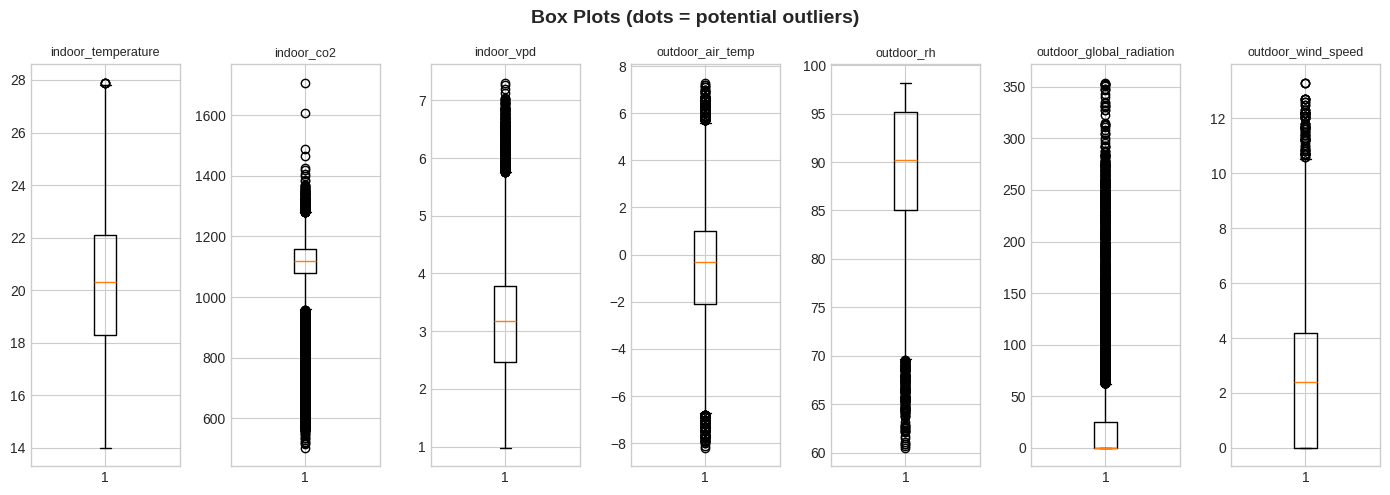

In [12]:
#BOX PLOTS to show outliers

fig, axes = plt.subplots(1, 7, figsize=(14, 5))

for i, col in enumerate(sensor_columns):
    axes[i].boxplot(fetched_data[col].dropna())
    axes[i].set_title(col, fontsize=9)


plt.suptitle('Box Plots (dots = potential outliers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 4. Data Preprocessing

Preparing data for models by
1. Selecting relevant features (continuous environmental variables)
2. Handling missing values
3. Normalising features by using StandardScaler

In [13]:
# Selecting features to use
# we only use continuous sensor measurements, excluding timestamp, binary values (0/1), unknown columns

feature_columns = [
    'indoor_temperature',        #Temperature inside greenhouse
    'indoor_co2',                #CO2 level inside
    'indoor_vpd',                #Vapour pressure deficit
    'outdoor_air_temp',          #Temperature outside
    'outdoor_rh',                #Humidity outside
    'outdoor_global_radiation',  #Sunlight
    'outdoor_wind_speed'         #Wind speed
]
#feature table with chosen columns
df_features = fetched_data[feature_columns].copy()
print(f"In total {len(feature_columns)} features:")
for col in feature_columns:
    print(f"  - {col}")
print()

print(f"Feature table shape: {df_features.shape}")

In total 7 features:
  - indoor_temperature
  - indoor_co2
  - indoor_vpd
  - outdoor_air_temp
  - outdoor_rh
  - outdoor_global_radiation
  - outdoor_wind_speed

Feature table shape: (10081, 7)


In [14]:
#Handling missing values
missing_before = df_features.isnull().sum().sum()
print(f"Missing values: {missing_before}")

#filling any missing values (if they exist)
df_features = df_features.ffill().bfill()

if missing_before == 0:
    print("No missing values found ")
else:
    print(f"Filled {missing_before} missing values")

Missing values: 0
No missing values found 


In [15]:
#Normalising the data
#ensuring all features are treated equally by all models

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(df_scaled, columns=feature_columns)

print("Data normalised:")
print("\nAfter scaling (mean should be ~0, std should be ~1):")
print()
print()
print(df_scaled.describe().round(2))



Data normalised:

After scaling (mean should be ~0, std should be ~1):


       indoor_temperature  indoor_co2  indoor_vpd  outdoor_air_temp  \
count            10081.00    10081.00    10081.00          10081.00   
mean                -0.00        0.00       -0.00              0.00   
std                  1.00        1.00        1.00              1.00   
min                 -1.94       -3.59       -2.02             -2.86   
25%                 -0.59        0.04       -0.68             -0.64   
50%                  0.04        0.30       -0.04              0.02   
75%                  0.60        0.54        0.50              0.50   
max                  2.41        4.00        3.66              2.79   

       outdoor_rh  outdoor_global_radiation  outdoor_wind_speed  
count    10081.00                  10081.00            10081.00  
mean         0.00                     -0.00               -0.00  
std          1.00                      1.00                1.00  
min         -3.91      

---
## 5. Anomaly Detection Methods

Implementing and comparing three anomaly detection algorithms:

| Method | Type | Description |
|--------|------|-------------|
| Isolation Forest | Tree-based | Isolates anomalies by randomly partitioning the feature space |
| Local Outlier Factor | Density-based | Measures how isolated a point is compared to its neighbours |
| One-Class SVM | Boundary-based | Learns a decision boundary that encloses normal data |


In [16]:
#Setting contamination rate

# the percentage% of data we expect to be anomalies
#     - 5% is a reasonable assumption for sensor data

contaminationrate = 0.05

print(f"Contamination rate: {contaminationrate*100}%")
print(f"Expected anomalies: ~{int(len(df_scaled) * contaminationrate)} out of {len(df_scaled)}")

Contamination rate: 5.0%
Expected anomalies: ~504 out of 10081


In [17]:
# MODEL 1: ISOLATION FOREST

#  Builds 100 random trees in the forest
#  Each tree attempts to isolate points using random splits
#  Anomalies get isolated quickly (short path) while normal points take longer to isolate (long path)

print("Training Isolation Forest...")

#the model
model_iforest = IsolationForest(
    n_estimators=100,        #number of trees
    contamination=contaminationrate,
    max_samples='auto',
    random_state=42          #for reproducibility
)

# Train and predict
# If returns: 1 = normal
#            -1 = anomaly
pred_forest = model_iforest.fit_predict(df_scaled)

# Count of anomalies and normal points
anomalies_iforest = (pred_forest == -1).sum()
normal_iforest = (pred_forest == 1).sum()
pct_anomalies_iforest = (anomalies_iforest / len(pred_forest)) * 100

print(f"Found {anomalies_iforest} anomalies ({pct_anomalies_iforest:.2f}%) and {normal_iforest} normal points")

Training Isolation Forest...
Found 504 anomalies (5.00%) and 9577 normal points


In [18]:
# MODEL 2: ONE-CLASS SVM

# Draws a boundary around the normal data
# Uses RBF kernel to find the non-linear boundaries
# The points outside the boundary are the anomalies

print("Training One-Class SVM...")

#the model
model_onecsvm= OneClassSVM(
    kernel='rbf',            # boundary type(RBF = curved)
    nu=contaminationrate,    # contamination
    gamma='scale'            # Automatic parameter
)

# Train and predict
pred_1csvm = model_onecsvm.fit_predict(df_scaled)

# Count of anomalies and normal points
anomalies_ocsvm = (pred_1csvm == -1).sum()
normal_ocsvm = (pred_1csvm == 1).sum()
perc_anomalies_ocsvm = (anomalies_ocsvm / len(pred_1csvm)) * 100

print(f"Found {anomalies_ocsvm} anomalies ({perc_anomalies_ocsvm :.2f}%) and {normal_ocsvm } normal points")


Training One-Class SVM...
Found 503 anomalies (4.99%) and 9578 normal points


In [19]:
# MODEL 3: LOCAL OUTLIER FACTOR

# For each point, it looks at its 20 nearest neighbours
# Compares the point's density to neighbours' density
# If much less dense than neighbours then its an anomaly

print("Training Local Outlier Factor...")

# the model
model_lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contaminationrate
)

# Train and predict
pred_lof = model_lof.fit_predict(df_scaled)

# Count of anomalies and normal points
anomalies_lof = (pred_lof == -1).sum()
normal_lof = (pred_lof == 1).sum()
perc_anomalies_lof = (anomalies_lof / len(pred_lof)) * 100

print(f"Found {anomalies_lof} anomalies ({perc_anomalies_lof:.2f}%) and {normal_lof} normal points")

Training Local Outlier Factor...
Found 504 anomalies (5.00%) and 9577 normal points


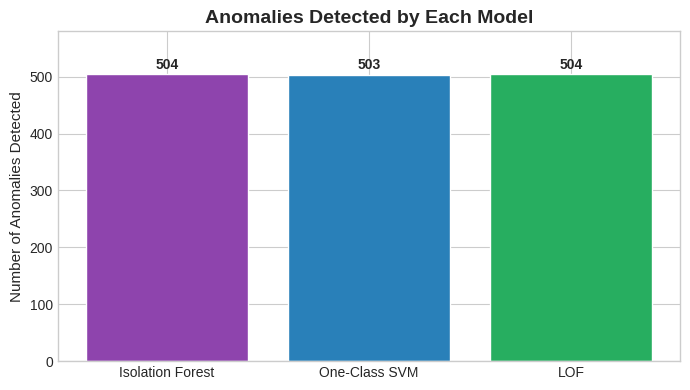

In [20]:
# INDIVIDUAL MODEL COMPARISON

fig, ax = plt.subplots(figsize=(7, 4))

models = ['Isolation Forest', 'One-Class SVM', 'LOF']
counts = [ (pred_forest == -1).sum(),(pred_1csvm == -1).sum(),(pred_lof == -1).sum()]
colors = ['#8E44AD', '#2980B9', '#27AE60']
thebars = ax.bar(models, counts, color=colors, edgecolor='white')

#the count of labels on bars
for bar, count in zip(thebars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Number of Anomalies Detected', fontsize=11)
ax.set_title('Anomalies Detected by Each Model', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.show()


---

## 6. Combining Models (Ensemble Voting)

In [21]:
# MAJORITY VOTING
# results table
results = fetched_data.copy()

# Adds each model's prediction,  1 = anomaly, 0 = normal
results['iforest_anomaly'] = (pred_forest == -1).astype(int)
results['ocsvm_anomaly'] = (pred_1csvm == -1).astype(int)
results['lof_anomaly'] = (pred_lof == -1).astype(int)

# counting how many models say "anomaly" for each point
results['vote_count'] = (results['iforest_anomaly'] +
                         results['ocsvm_anomaly'] +
                         results['lof_anomaly'])

# final decision: anomaly if 2 or more models agree
results['isanomaly1'] = (results['vote_count'] >= 2).astype(int)

ensemble_anomalies = results['isanomaly1'].sum()
perc_ensemble_anomalies = (ensemble_anomalies / len(results)) * 100
print(f"Ensemble result (2+ models agree): {ensemble_anomalies} anomalies ({perc_ensemble_anomalies:.2f}%)")

Ensemble result (2+ models agree): 227 anomalies (2.25%)


In [22]:
# Showing the voting breakdown
print("\nVoting breakdown:")
print("="*40)

# number of points that got 0, 1, 2, or 3 votes
vote_counts = results['vote_count'].value_counts().sort_index()

for votes, count in vote_counts.items():
    perc = count / len(results) * 100
    if votes == 0:
        label = "0 models (normal)"
    elif votes == 1:
        label = "1 model only"
    elif votes == 2:
        label = "2 models agree -> ANOMALY"
    else:
        label = "3 models agree -> ANOMALY"
    print(f"  {label}: {count} points ({perc:.1f}%)")


Voting breakdown:
  0 models (normal): 8802 points (87.3%)
  1 model only: 1052 points (10.4%)
  2 models agree -> ANOMALY: 222 points (2.2%)
  3 models agree -> ANOMALY: 5 points (0.0%)


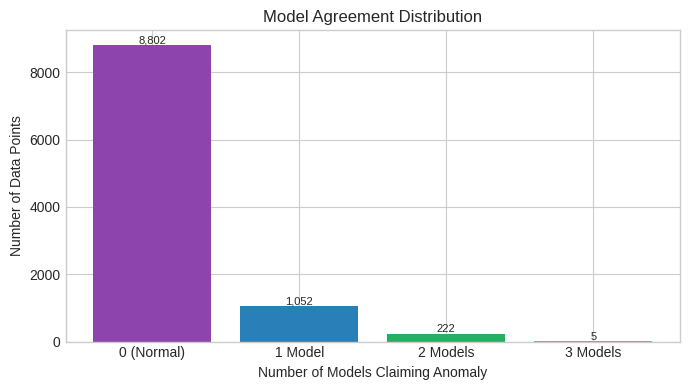

Points with 2+ votes (right of red line) are flagged as anomalies


In [30]:
# PLOTTING VOTING BREAKDOWN
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#8E44AD','#2980B9','#27AE60', '#DB7093']
bars = ax.bar(vote_counts.index, vote_counts.values,
              color=[colors[i] for i in vote_counts.index])

ax.set_xlabel('Number of Models Claiming Anomaly')
ax.set_ylabel('Number of Data Points')
ax.set_title('Model Agreement Distribution')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0 (Normal)', '1 Model', '2 Models', '3 Models'])

# adding numbers on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 50,
            f'{int(height):,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Points with 2+ votes (right of red line) are flagged as anomalies")

---

## 7. Visualising Results

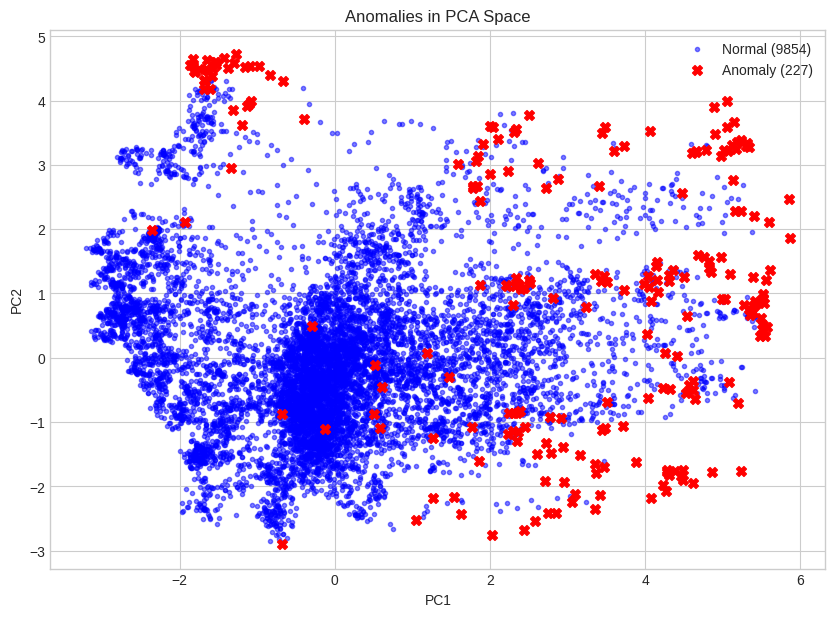

In [24]:
# PCA PLOT
pca = PCA(n_components=2)
data_2d = pca.fit_transform(df_scaled) #transform data to 2D

plt.figure(figsize=(10, 7))
normal = results['isanomaly1'] == 0
anomaly = results['isanomaly1'] == 1

#plotting normal points
plt.scatter(data_2d[normal, 0], data_2d[normal, 1], c='blue', alpha=0.5, s=9, label=f'Normal ({normal.sum()})')
#plotting anomaly points
plt.scatter(data_2d[anomaly, 0], data_2d[anomaly, 1], c='red', s=50, marker='X', label=f'Anomaly ({anomaly.sum()})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Anomalies in PCA Space')
plt.legend()
plt.show()

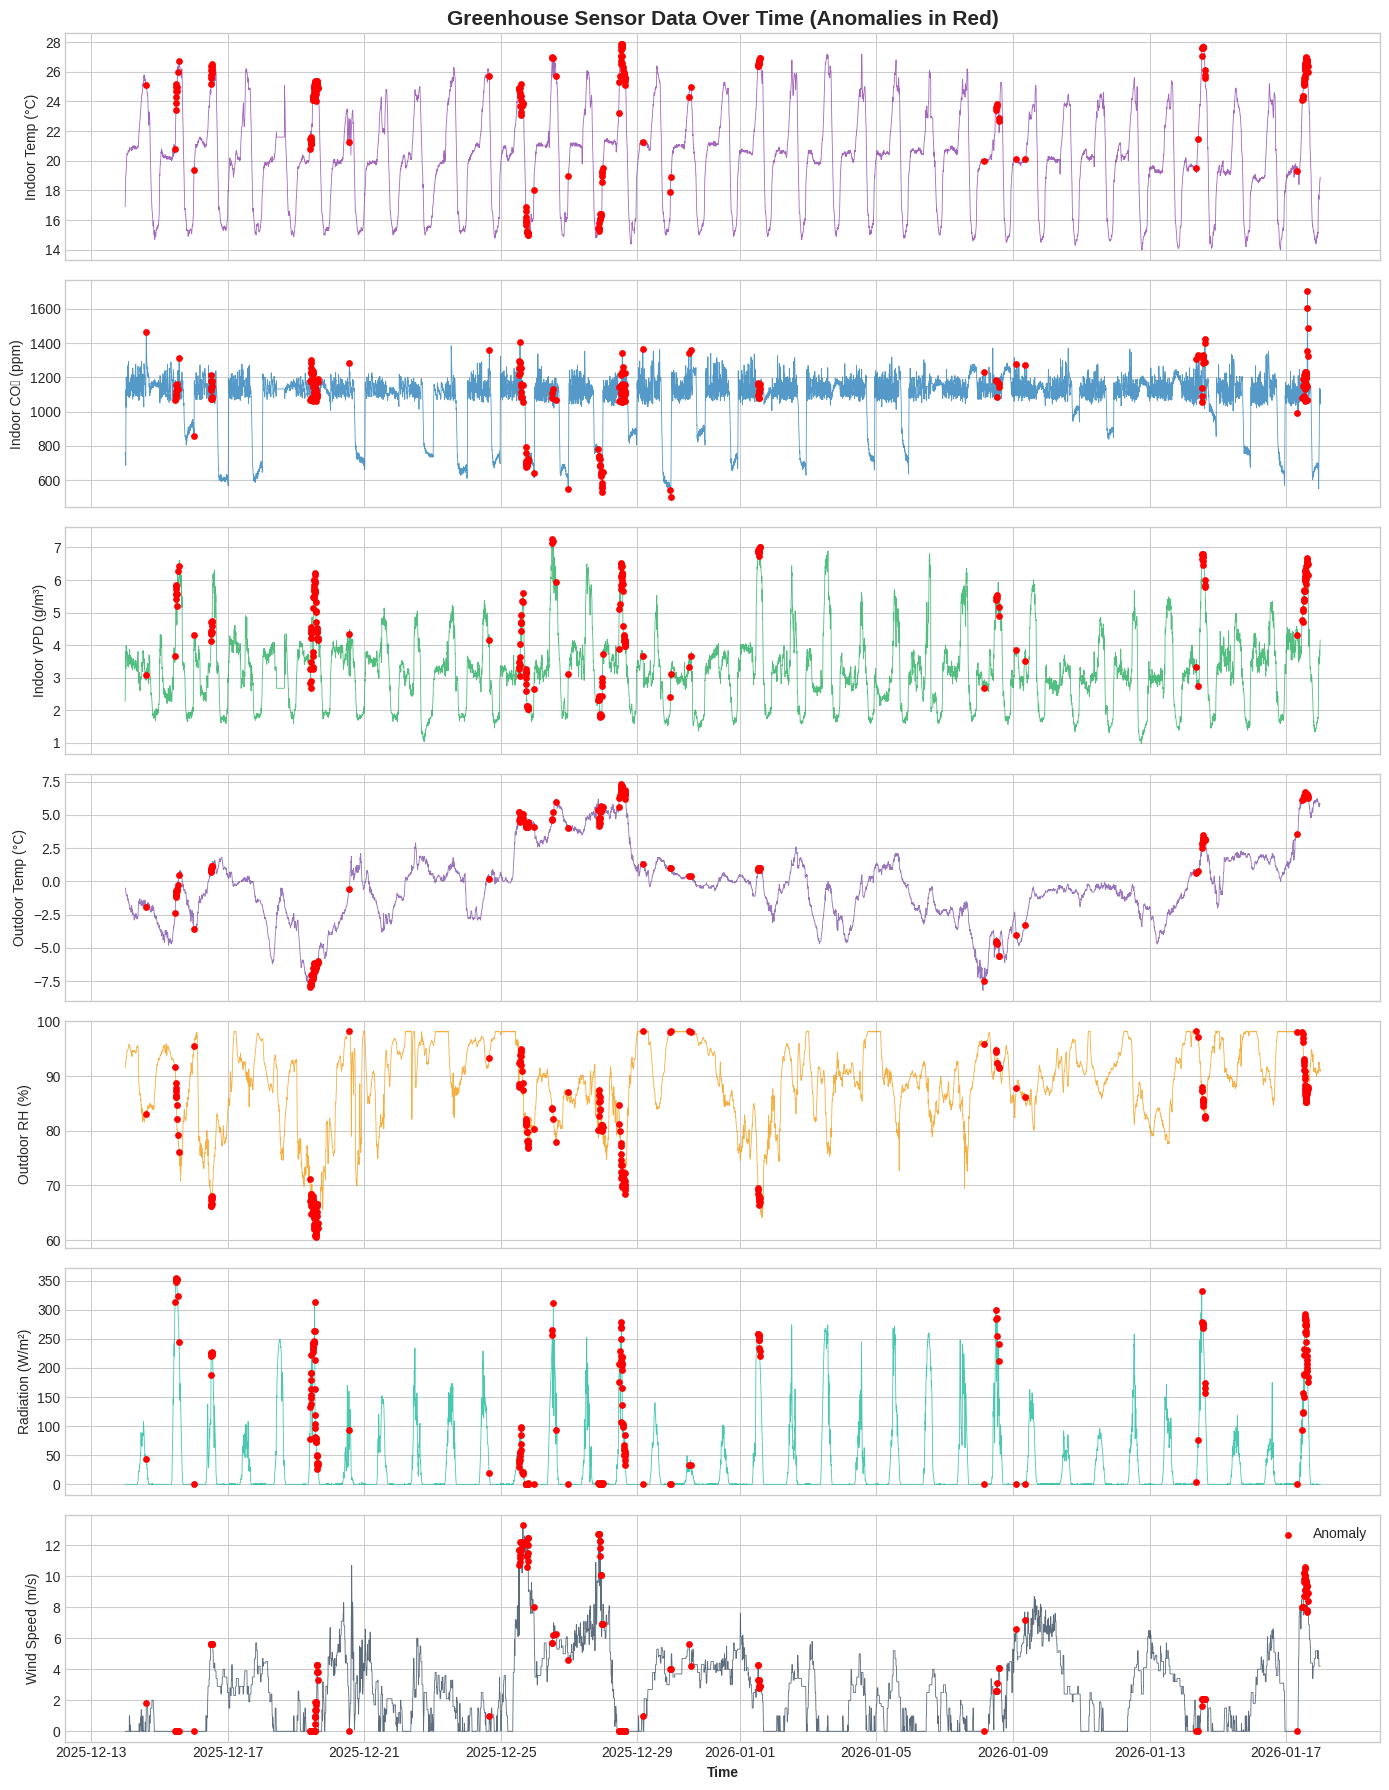

In [31]:
# Visualising all 7 sensor features over time WITH ANOMALIES

fig, axes = plt.subplots(7, 1, figsize=(14, 18), sharex=True)

axes[0].set_title('Greenhouse Sensor Data Over Time (Anomalies in Red)', fontsize=15, fontweight='bold')
anomaly = results['isanomaly1'] == 1

# Plot 1: Indoor Temperature
axes[0].plot(results['timestamp'], results['indoor_temperature'],
             color='#8E44AD', linewidth=0.6, alpha=0.8)
axes[0].scatter(results.loc[anomaly, 'timestamp'], results.loc[anomaly, 'indoor_temperature'],
                c='red', s=15, zorder=5)
axes[0].set_ylabel('Indoor Temp (°C)', fontsize=10)

# Plot 2: Indoor CO2
axes[1].plot(results['timestamp'], results['indoor_co2'],
             color='#2980B9', linewidth=0.6, alpha=0.8)
axes[1].scatter(results.loc[anomaly, 'timestamp'], results.loc[anomaly, 'indoor_co2'],
                c='red', s=15, zorder=5)
axes[1].set_ylabel('Indoor CO₂ (ppm)', fontsize=10)

# Plot 3: Indoor VPD
axes[2].plot(results['timestamp'], results['indoor_vpd'],
             color='#27AE60', linewidth=0.6, alpha=0.8)
axes[2].scatter(results.loc[anomaly, 'timestamp'], results.loc[anomaly, 'indoor_vpd'],
                c='red', s=15, zorder=5)
axes[2].set_ylabel('Indoor VPD (g/m³)', fontsize=10)

# Plot 4: Outdoor Temperature
axes[3].plot(results['timestamp'], results['outdoor_air_temp'],
             color='#7E55AB', linewidth=0.6, alpha=0.8)
axes[3].scatter(results.loc[anomaly, 'timestamp'], results.loc[anomaly, 'outdoor_air_temp'],
                c='red', s=15, zorder=5)
axes[3].set_ylabel('Outdoor Temp (°C)', fontsize=10)

# Plot 5: Outdoor Humidity
axes[4].plot(results['timestamp'], results['outdoor_rh'],
             color='#F39C12', linewidth=0.6, alpha=0.8)
axes[4].scatter(results.loc[anomaly, 'timestamp'], results.loc[anomaly, 'outdoor_rh'],
                c='red', s=15, zorder=5)
axes[4].set_ylabel('Outdoor RH (%)', fontsize=10)

# Plot 6: Outdoor Radiation
axes[5].plot(results['timestamp'], results['outdoor_global_radiation'],
             color='#1ABC9C', linewidth=0.6, alpha=0.8)
axes[5].scatter(results.loc[anomaly, 'timestamp'], results.loc[anomaly, 'outdoor_global_radiation'],
                c='red', s=15, zorder=5)
axes[5].set_ylabel('Radiation (W/m²)', fontsize=10)

# Plot 7: Outdoor Wind Speed
axes[6].plot(results['timestamp'], results['outdoor_wind_speed'],
             color='#34495E', linewidth=0.6, alpha=0.8)
axes[6].scatter(results.loc[anomaly, 'timestamp'], results.loc[anomaly, 'outdoor_wind_speed'],
                c='red', s=15, zorder=5, label='Anomaly')
axes[6].set_ylabel('Wind Speed (m/s)', fontsize=10)
axes[6].legend(loc='upper right')

axes[6].set_xlabel('Time', fontsize=10, fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

## 8. Analysing the Anomalies

In [32]:
# COMPARING NORMAL VS ANOMALY VALUES
# Getting normal and anomaly data
normal_data = results[results['isanomaly1'] == 0][feature_columns]
anomaly_data = results[results['isanomaly1'] == 1][feature_columns]

print("The average values comparison:")
print("-"*63)
comp = pd.DataFrame({
    'Normal Mean': normal_data.mean().round(2),
    'Anomaly Mean': anomaly_data.mean().round(2),
    'Difference': (anomaly_data.mean() - normal_data.mean()).round(2)
})

print(comp)

The average values comparison:
---------------------------------------------------------------
                          Normal Mean  Anomaly Mean  Difference
indoor_temperature              20.11         23.75        3.65
indoor_co2                    1072.54       1093.03       20.49
indoor_vpd                       3.19          4.80        1.61
outdoor_air_temp                -0.41          1.70        2.11
outdoor_rh                      89.37         79.05      -10.33
outdoor_global_radiation        26.62        150.14      123.52
outdoor_wind_speed               2.52          4.77        2.25


In [33]:
# SAMPLE ANOMALIES

print("Sample of detected anomalies:")
print("-"*120)

columns = ['timestamp', 'indoor_temperature', 'indoor_co2', 'indoor_vpd',
           'outdoor_air_temp', 'outdoor_rh', 'outdoor_global_radiation',
           'outdoor_wind_speed', 'vote_count']

sample = results[results['isanomaly1'] == 1][columns].head(10)
print(sample.to_string(index=False))

Sample of detected anomalies:
------------------------------------------------------------------------------------------------------------------------
                 timestamp  indoor_temperature  indoor_co2  indoor_vpd  outdoor_air_temp  outdoor_rh  outdoor_global_radiation  outdoor_wind_speed  vote_count
2025-12-14 14:50:03.839997                25.1      1466.0    3.082543              -1.9        83.0                      43.0                 1.8           2
2025-12-15 11:04:59.520004                20.8      1068.0    3.673948              -2.4        91.7                     313.0                 0.0           2
2025-12-15 11:34:56.639999                23.4      1119.0    5.413888              -1.2        88.8                     348.0                 0.0           2
2025-12-15 11:39:59.039998                23.9      1097.0    5.569304              -0.9        87.9                     353.0                 0.0           2
2025-12-15 11:45:01.439998                24.3      10

In [34]:
# SAVING RESULTS DATA
results.to_csv('anomaly_results.csv', index=False)
print("Saved: anomaly_results.csv")

Saved: anomaly_results.csv


In [35]:
print("FINAL SUMMARY")
print("-"*60)

print(f"\nDATA:")
print(f"  Source: Greenhouse API")
print(f"  Records: {len(results)}")
print(f"  Features: {len(feature_columns)}")

print(f"\nMODELS:")
print(f"  Isolation Forest:     {anomalies_iforest} anomalies")
print(f"  One-Class SVM:        {anomalies_ocsvm} anomalies")
print(f"  Local Outlier Factor: {anomalies_lof} anomalies")

print(f"\nENSEMBLE:")
print(f"  Anomalies: {ensemble_anomalies} ({ensemble_anomalies/len(results)*100:.1f}%)")
print(f"  Normal:    {len(results) - ensemble_anomalies} ({(len(results) - ensemble_anomalies)/len(results)*100:.1f}%)")


FINAL SUMMARY
------------------------------------------------------------

DATA:
  Source: Greenhouse API
  Records: 10081
  Features: 7

MODELS:
  Isolation Forest:     504 anomalies
  One-Class SVM:        503 anomalies
  Local Outlier Factor: 504 anomalies

ENSEMBLE:
  Anomalies: 227 (2.3%)
  Normal:    9854 (97.7%)
